# Electronic Waste Management - Comprehensive EDA

This notebook performs a full exploratory data analysis (EDA) on `electronics_pricing_dataset.csv` to understand:
- data quality and structure
- behavior of pricing and durability features
- category-level patterns (product type, brand, usage pattern)
- a practical **e-waste readiness heuristic** for downstream modeling

In [1]:
# Core imports
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

plt.style.use('ggplot')
RANDOM_STATE = 42

In [2]:
# Load dataset
df = pd.read_csv('electronics_pricing_dataset.csv')

print(f'Shape: {df.shape}')
print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')
print(df.columns)
df.head()

Shape: (15000, 10)
Rows: 15,000 | Columns: 10
Index(['Product_Type', 'Brand', 'Build_Quality', 'User_Lifespan', 'Usage_Pattern', 'Expiry_Years', 'Condition', 'Original_Price', 'Used_Duration',
       'Current_Price'],
      dtype='str')


,Product_Type,Brand,Build_Quality,User_Lifespan,Usage_Pattern,Expiry_Years,Condition,Original_Price,Used_Duration,Current_Price
0,Laptop,HP,1,6.9,Moderate,7.0,3,118741,12,500.00
1,Smartphone,OnePlus,5,3.9,Moderate,4.8,5,73040,4,12173.33
2,Laptop,Lenovo,3,6.1,Moderate,6.6,1,83604,5,8107.05
3,TV,OnePlus,5,13.7,Heavy,14.4,2,120656,1,61752.41
4,DSLR Camera,Sony,2,9.7,Moderate,10.0,2,83435,6,21359.36


In [3]:
# Schema and quality checks
print('--- Column types ---')
display(df.dtypes.to_frame('dtype'))

missing = df.isna().sum().sort_values(ascending=False)
duplicates = df.duplicated().sum()

print('--- Data quality summary ---')
print(f'Total missing values: {int(missing.sum())}')
print(f'Duplicate rows: {int(duplicates)}')

if missing.sum() > 0:
    display(missing[missing > 0].to_frame('missing_count'))
else:
    print('No missing values found.')

--- Column types ---


,dtype
Product_Type,str
Brand,str
Build_Quality,int64
User_Lifespan,float64
Usage_Pattern,str
Expiry_Years,float64
Condition,int64
Original_Price,int64
Used_Duration,int64
Current_Price,float64


--- Data quality summary ---
Total missing values: 0
Duplicate rows: 0
No missing values found.


In [4]:
# Separate numeric/categorical columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

print('Numeric columns:', num_cols)
print('Categorical columns:', cat_cols)

display(df[num_cols].describe().T)

# Useful quantiles for heavy-tailed price behavior
q = df[['Original_Price', 'Current_Price']].quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
display(q)

Numeric columns: ['Build_Quality', 'User_Lifespan', 'Expiry_Years', 'Condition', 'Original_Price', 'Used_Duration', 'Current_Price']
Categorical columns: ['Product_Type', 'Brand', 'Usage_Pattern']


,count,mean,std,min,25%,50%,75%,max
Build_Quality,15000.0,3.009000,1.417222,1.0,2.0,3.00,4.0000,5.0
User_Lifespan,15000.0,7.475627,3.413485,2.0,4.7,6.60,9.8000,15.0
Expiry_Years,15000.0,7.944747,3.429139,1.9,5.2,7.10,10.3000,16.0
Condition,15000.0,3.020600,1.413851,1.0,2.0,3.00,4.0000,5.0
Original_Price,15000.0,63515.623667,43323.833249,3014.0,31168.0,51582.50,82841.7500,199958.0
Used_Duration,15000.0,6.537133,3.458451,1.0,4.0,7.00,10.0000,12.0
Current_Price,15000.0,13111.416907,20389.243816,500.0,500.0,4134.97,17870.2525,178924.7


,Original_Price,Current_Price
0.01,6301.97,500.0000
0.05,12759.60,500.0000
0.25,31168.00,500.0000
0.50,51582.50,4134.9700
0.75,82841.75,17870.2525
0.95,153257.50,54479.0330
0.99,189484.07,96392.2984


In [5]:
# Categorical profile
for c in cat_cols:
    print(f'\n=== {c} ===')
    print(f'Unique values: {df[c].nunique()}')
    display(df[c].value_counts(dropna=False).head(15).to_frame('count'))


=== Product_Type ===
Unique values: 12


,count
Product_Type,
Tablet,1297
Microwave,1280
DSLR Camera,1272
Air Conditioner,1267
Smartwatch,1252
TV,1247
Electric Scooter,1242
Washing Machine,1237
Laptop,1235



=== Brand ===
Unique values: 38


,count
Brand,
Samsung,1822
LG,1267
Apple,1009
Sony,990
IFB,532
Lenovo,509
Bosch,503
Whirlpool,495
OnePlus,441



=== Usage_Pattern ===
Unique values: 3


,count
Usage_Pattern,
Light,5066
Heavy,4984
Moderate,4950


In [6]:
# Feature engineering for e-waste analysis
eda = df.copy()

eda['Residual_Value_Pct'] = (eda['Current_Price'] / eda['Original_Price']) * 100
eda['Depreciation_Value'] = eda['Original_Price'] - eda['Current_Price']
eda['Usage_to_Expiry_Ratio'] = eda['Used_Duration'] / eda['Expiry_Years']
eda['Years_to_Expiry'] = eda['Expiry_Years'] - eda['Used_Duration']

# Practical target heuristic (can be replaced by policy-specific rules later)4
eda['Ewaste_Ready'] = ((eda['Used_Duration'] >= eda['Expiry_Years']) |
                       (eda['Condition'] <= 2) |
                       (eda['Current_Price'] <= 1000)).astype(int)

display(eda[['Residual_Value_Pct', 'Depreciation_Value', 'Usage_to_Expiry_Ratio', 'Years_to_Expiry', 'Ewaste_Ready']].describe().T)

,count,mean,std,min,25%,50%,75%,max
Residual_Value_Pct,15000.0,20.798260,23.213394,0.250053,1.145561,11.194698,35.579566,93.506489
Depreciation_Value,15000.0,50404.206759,38640.022355,1043.570000,21477.592500,39158.000000,69228.860000,199458.000000
Usage_to_Expiry_Ratio,15000.0,1.005690,0.755181,0.063291,0.439560,0.819672,1.388889,6.000000
Years_to_Expiry,15000.0,1.407613,4.894193,-10.000000,-2.300000,1.300000,4.800000,14.800000
Ewaste_Ready,15000.0,0.651333,0.476564,0.000000,0.000000,1.000000,1.000000,1.000000


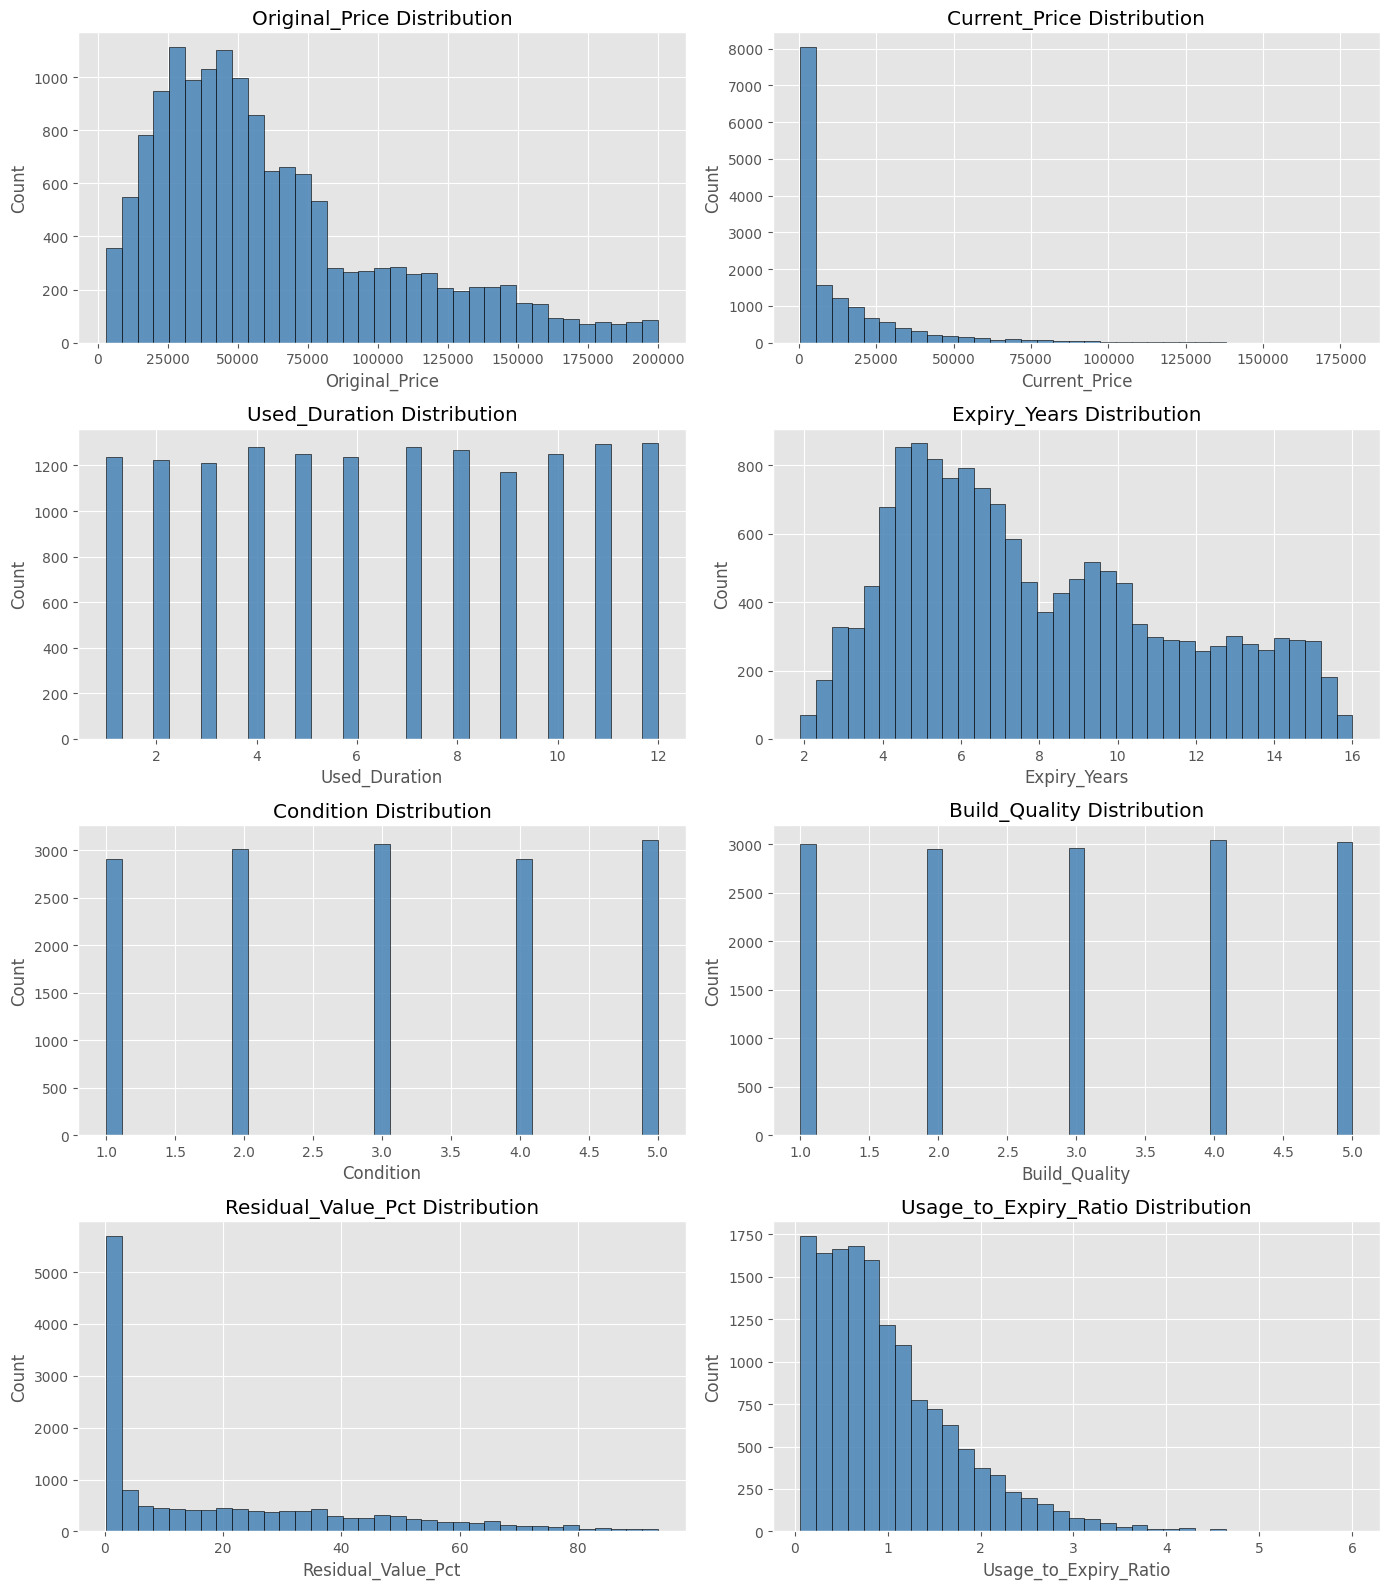

In [7]:
# Univariate numeric distributions
plot_cols = [
    'Original_Price', 'Current_Price', 'Used_Duration', 'Expiry_Years',
    'Condition', 'Build_Quality', 'Residual_Value_Pct', 'Usage_to_Expiry_Ratio'
]

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, c in enumerate(plot_cols):
    axes[i].hist(eda[c], bins=35, color='steelblue', alpha=0.85, edgecolor='black')
    axes[i].set_title(f'{c} Distribution')
    axes[i].set_xlabel(c)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

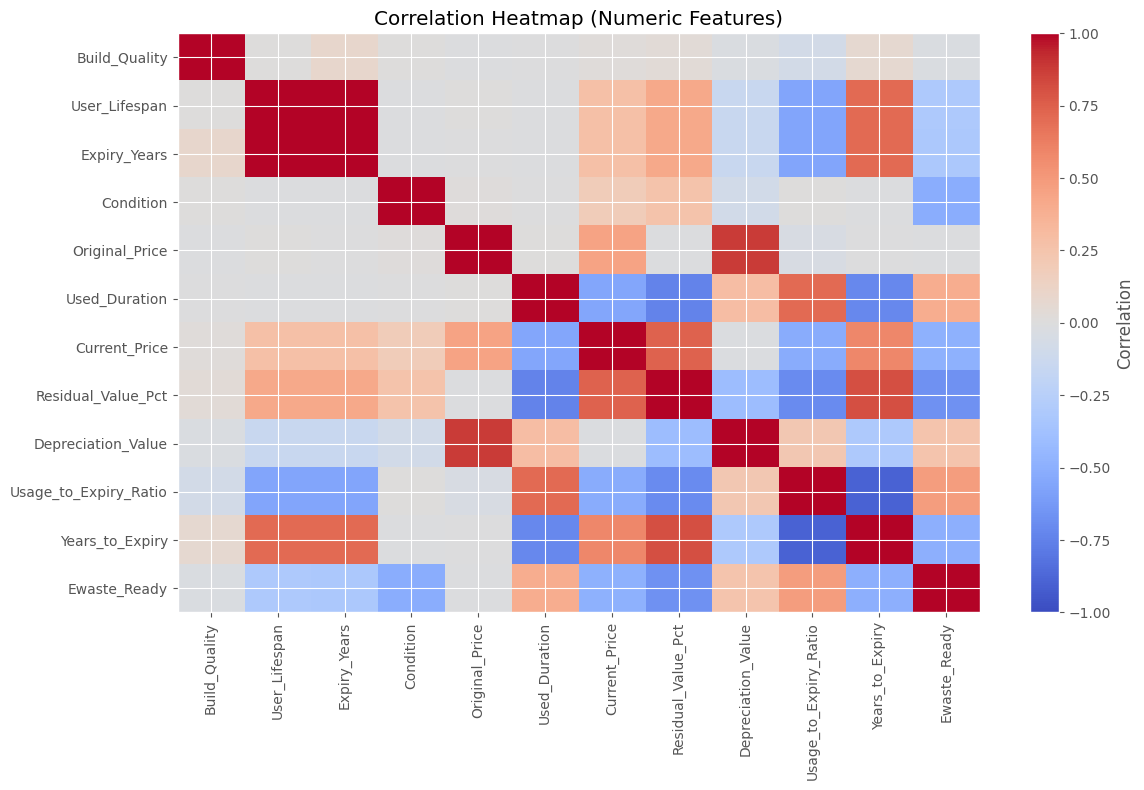

,corr_with_Current_Price
Current_Price,1.000000
Residual_Value_Pct,0.736477
Years_to_Expiry,0.583024
Original_Price,0.452614
Expiry_Years,0.277923
User_Lifespan,0.277353
Condition,0.181345
Build_Quality,0.022520
Depreciation_Value,-0.020193
Ewaste_Ready,-0.485281


In [8]:
# Correlation matrix (numeric only)
corr_cols = [c for c in eda.columns if pd.api.types.is_numeric_dtype(eda[c])]
corr = eda[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(corr.values, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)
ax.set_title('Correlation Heatmap (Numeric Features)')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Correlation')
plt.tight_layout()
plt.show()

display(corr['Current_Price'].sort_values(ascending=False).to_frame('corr_with_Current_Price'))

,Product_Type,count,avg_original_price,avg_current_price,median_current_price,avg_residual_pct,ewaste_ready_rate
9,TV,1247,105591.701684,34228.602670,25912.570,32.425637,0.456295
6,Refrigerator,1228,49901.922638,15773.170480,12893.680,31.678653,0.471498
1,DSLR Camera,1272,120351.751572,26437.501958,12611.115,22.230041,0.629717
0,Air Conditioner,1267,42060.176006,13820.939803,11830.900,32.431581,0.466456
11,Washing Machine,1237,36639.802749,11724.161504,9847.670,32.069883,0.484236
5,Microwave,1280,17443.207813,3908.048609,1684.630,22.579868,0.658594
3,Gaming Console,1209,55029.759305,8095.162366,500.000,14.764739,0.747725
2,Electric Scooter,1242,110067.089372,17941.002013,500.000,16.404807,0.710950
7,Smartphone,1234,63227.601297,5679.928509,500.000,8.923156,0.833874
4,Laptop,1235,89542.176518,11591.326907,500.000,13.385823,0.753846


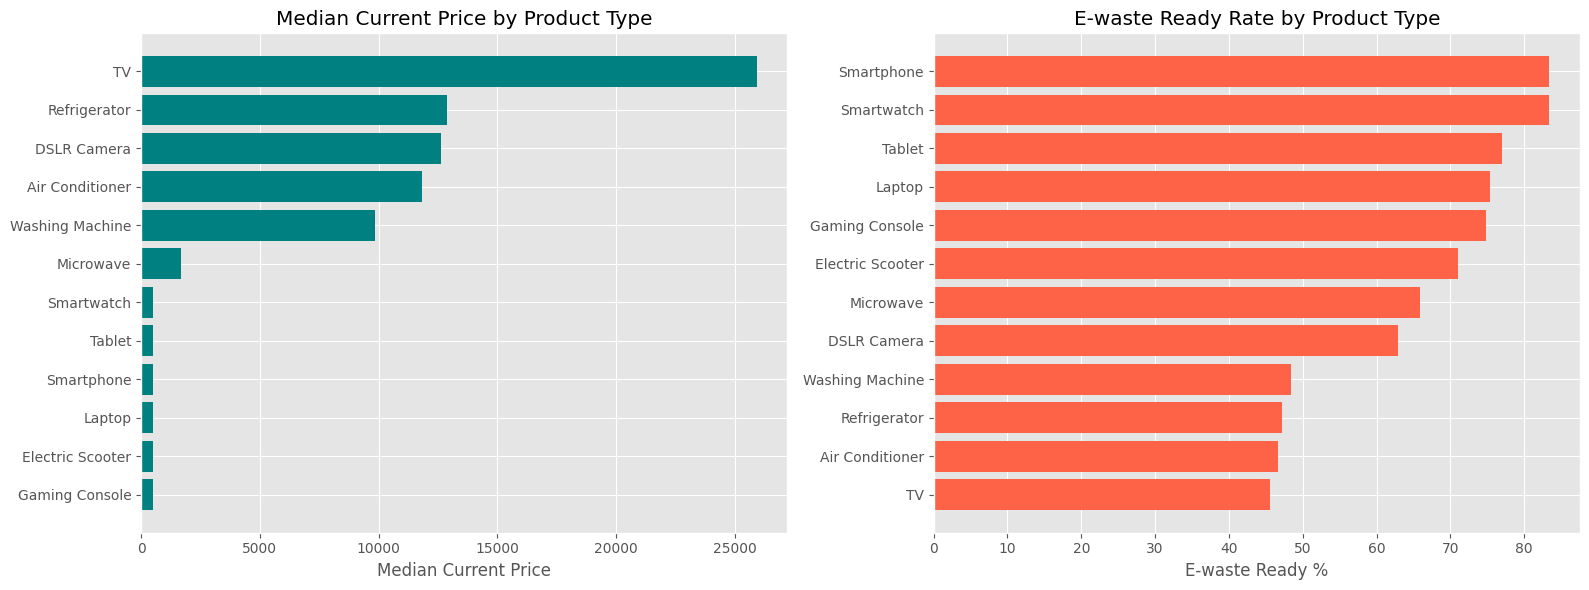

In [9]:
# Product-level pricing behavior
prod_stats = (
    eda.groupby('Product_Type', as_index=False)
       .agg(
            count=('Product_Type', 'size'),
            avg_original_price=('Original_Price', 'mean'),
            avg_current_price=('Current_Price', 'mean'),
            median_current_price=('Current_Price', 'median'),
            avg_residual_pct=('Residual_Value_Pct', 'mean'),
            ewaste_ready_rate=('Ewaste_Ready', 'mean')
        )
       .sort_values('median_current_price', ascending=False)
)

display(prod_stats)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

tmp = prod_stats.sort_values('median_current_price', ascending=True)
axes[0].barh(tmp['Product_Type'], tmp['median_current_price'], color='teal')
axes[0].set_title('Median Current Price by Product Type')
axes[0].set_xlabel('Median Current Price')

tmp2 = prod_stats.sort_values('ewaste_ready_rate', ascending=True)
axes[1].barh(tmp2['Product_Type'], tmp2['ewaste_ready_rate'] * 100, color='tomato')
axes[1].set_title('E-waste Ready Rate by Product Type')
axes[1].set_xlabel('E-waste Ready %')

plt.tight_layout()
plt.show()

,Usage_Pattern,count,avg_used_duration,avg_current_price,avg_residual_pct,ewaste_ready_rate
0,Heavy,4984,6.507424,13133.425038,20.645285,0.659510
1,Light,5066,6.590209,13100.866332,20.748187,0.652586
2,Moderate,4950,6.512727,13100.055430,21.003531,0.641818


,Condition,count,avg_current_price,median_current_price,avg_residual_pct,ewaste_ready_rate
0,1,2908,7703.363343,2467.220,12.100675,1.000000
1,2,3006,10984.107059,3724.105,16.982488,1.000000
2,3,3065,12669.062166,4532.780,20.620226,0.428385
3,4,2911,15307.170890,5436.360,24.719221,0.419787
4,5,3110,18605.079482,6873.775,29.124478,0.424759


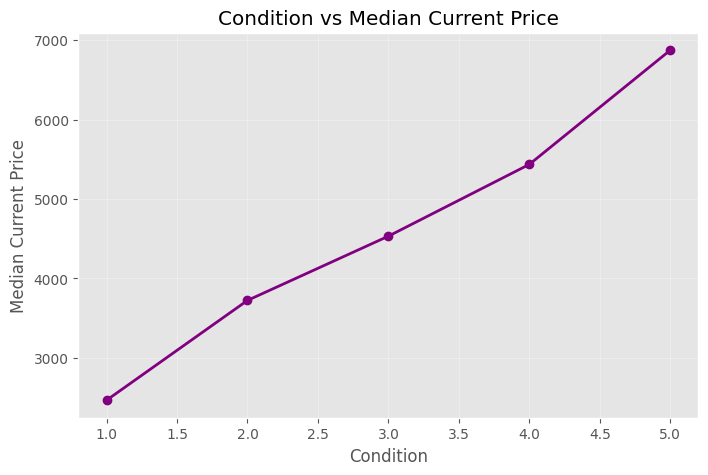

In [10]:
# Usage pattern and condition analysis
usage_stats = (
    eda.groupby('Usage_Pattern', as_index=False)
       .agg(
            count=('Usage_Pattern', 'size'),
            avg_used_duration=('Used_Duration', 'mean'),
            avg_current_price=('Current_Price', 'mean'),
            avg_residual_pct=('Residual_Value_Pct', 'mean'),
            ewaste_ready_rate=('Ewaste_Ready', 'mean')
        )
       .sort_values('avg_current_price', ascending=False)
)
display(usage_stats)

cond_stats = (
    eda.groupby('Condition', as_index=False)
       .agg(
            count=('Condition', 'size'),
            avg_current_price=('Current_Price', 'mean'),
            median_current_price=('Current_Price', 'median'),
            avg_residual_pct=('Residual_Value_Pct', 'mean'),
            ewaste_ready_rate=('Ewaste_Ready', 'mean')
        )
       .sort_values('Condition')
)
display(cond_stats)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cond_stats['Condition'], cond_stats['median_current_price'], marker='o', linewidth=2, color='purple')
ax.set_title('Condition vs Median Current Price')
ax.set_xlabel('Condition')
ax.set_ylabel('Median Current Price')
ax.grid(True, alpha=0.3)
plt.show()

Overall E-waste Ready Rate: 65.13%
Rule A (Used_Duration >= Expiry_Years): 40.51%
Rule B (Condition <= 2): 39.43%
Rule C (Current_Price <= 1000): 42.62%


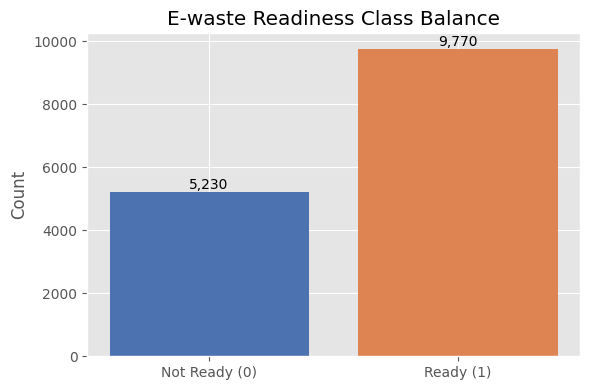

In [11]:
# Heuristic e-waste readiness deep-dive
overall_rate = eda['Ewaste_Ready'].mean() * 100
rule_a = (eda['Used_Duration'] >= eda['Expiry_Years']).mean() * 100
rule_b = (eda['Condition'] <= 2).mean() * 100
rule_c = (eda['Current_Price'] <= 1000).mean() * 100

print(f'Overall E-waste Ready Rate: {overall_rate:.2f}%')
print(f'Rule A (Used_Duration >= Expiry_Years): {rule_a:.2f}%')
print(f'Rule B (Condition <= 2): {rule_b:.2f}%')
print(f'Rule C (Current_Price <= 1000): {rule_c:.2f}%')

fig, ax = plt.subplots(figsize=(6, 4))
counts = eda['Ewaste_Ready'].value_counts().sort_index()
labels = ['Not Ready (0)', 'Ready (1)']
ax.bar(labels, counts.values, color=['#4c72b0', '#dd8452'])
ax.set_title('E-waste Readiness Class Balance')
ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + max(counts.values) * 0.01, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## EDA Summary (for modeling)

1. The dataset is clean (no missing values, no duplicate rows).
2. `Current_Price` is right-skewed and strongly tied to `Original_Price` and depreciation-related features.
3. `Used_Duration` and `Usage_to_Expiry_Ratio` show clear negative relationship with `Current_Price`.
4. Product categories differ significantly in residual value and e-waste readiness rates.
5. The heuristic `Ewaste_Ready` target is reasonably informative for building a first classification model.

Next step: use these engineered features to train
- a regression model for `Current_Price`
- a classification model for `Ewaste_Ready`